<a href="https://colab.research.google.com/github/LILIANAMARIAVILLA/MachineLearning/blob/main/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from google.colab import files

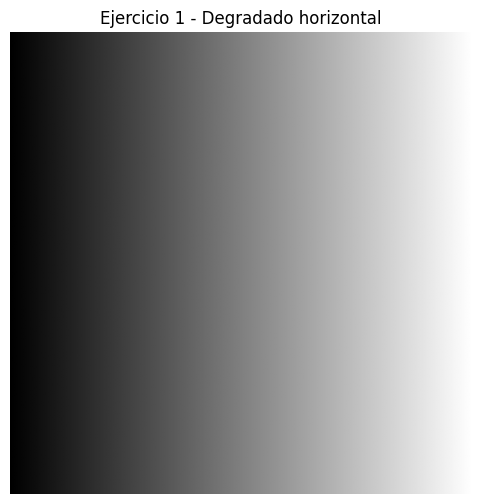

In [2]:
h, w = 512, 512

img1 = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        img1[i, j] = j // 2   # 0,0,1,1,2,2,...,255,255

plt.figure(figsize=(6,6))
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title("Ejercicio 1 - Degradado horizontal")
plt.axis('off')
plt.show()

imageio.imwrite('/content/resultado_ej1.png', img1)

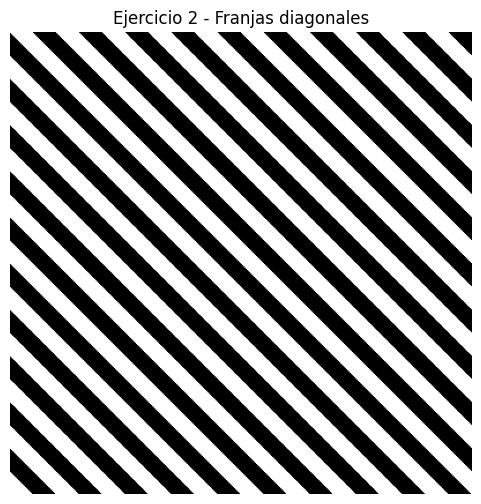

In [3]:
h, w = 400, 400

img2 = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if ((j - i) // 20) % 2 == 0:
            img2[i, j] = 255
        else:
            img2[i, j] = 0

plt.figure(figsize=(6,6))
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
plt.title("Ejercicio 2 - Franjas diagonales")
plt.axis('off')
plt.show()

imageio.imwrite('/content/resultado_ej2.png', img2)

Lena: (220, 220, 3)
Tiger: (218, 218, 3)


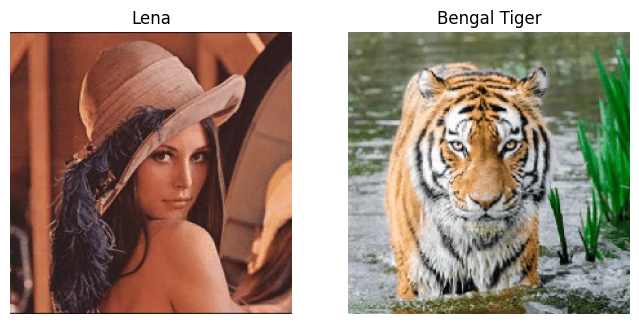

In [5]:
lena = imageio.imread('/content/846a71bd-bb00-402b-b406-82cd9fbb6047.jpg')
tiger = imageio.imread('/content/imagen_2026-02-27_060049481.png')

# Si alguna tiene canal alpha, lo quitamos con slicing
if lena.ndim == 3 and lena.shape[2] == 4:
    lena = lena[:, :, :3]

if tiger.ndim == 3 and tiger.shape[2] == 4:
    tiger = tiger[:, :, :3]

print("Lena:", lena.shape)
print("Tiger:", tiger.shape)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(lena)
plt.title("Lena")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(tiger)
plt.title("Bengal Tiger")
plt.axis('off')

plt.show()

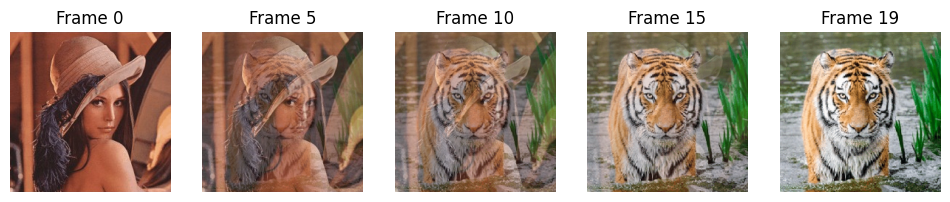

In [6]:
# Si no tienen el mismo tamaño, se recortan al mínimo común
h = min(lena.shape[0], tiger.shape[0])
w = min(lena.shape[1], tiger.shape[1])

lena3 = lena[:h, :w, :3]
tiger3 = tiger[:h, :w, :3]

num_frames = 20
frames = []

for k in range(num_frames):
    alpha = k / (num_frames - 1)
    frame = np.zeros((h, w, 3), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            for c in range(3):
                valor = (1 - alpha) * lena3[i, j, c] + alpha * tiger3[i, j, c]
                frame[i, j, c] = np.uint8(valor)

    frames.append(frame)

plt.figure(figsize=(12,3))
for n, idx in enumerate([0, 5, 10, 15, 19]):
    plt.subplot(1,5,n+1)
    plt.imshow(frames[idx])
    plt.title(f"Frame {idx}")
    plt.axis('off')
plt.show()

imageio.mimsave('/content/resultado_ej3.gif', frames, duration=0.4)

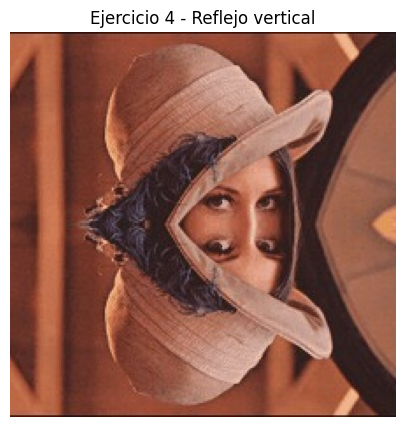

In [7]:
h, w, c = lena.shape
img4 = np.zeros((h, w, c), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if i < h // 2:
            img4[i, j, 0] = lena[i, j, 0]
            img4[i, j, 1] = lena[i, j, 1]
            img4[i, j, 2] = lena[i, j, 2]
        else:
            img4[i, j, 0] = lena[h - 1 - i, j, 0]
            img4[i, j, 1] = lena[h - 1 - i, j, 1]
            img4[i, j, 2] = lena[h - 1 - i, j, 2]

plt.figure(figsize=(7,5))
plt.imshow(img4)
plt.title("Ejercicio 4 - Reflejo vertical")
plt.axis('off')
plt.show()

imageio.imwrite('/content/resultado_ej4.png', img4)

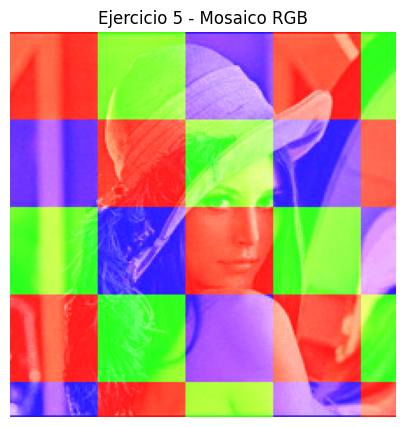

In [8]:
h, w, c = lena.shape
img5 = np.zeros((h, w, c), dtype=np.uint8)

tam_bloque = 50

for i in range(h):
    for j in range(w):
        # copiar primero el pixel original
        img5[i, j, 0] = lena[i, j, 0]
        img5[i, j, 1] = lena[i, j, 1]
        img5[i, j, 2] = lena[i, j, 2]

        # patrón del canal que se va a forzar a 255
        canal = ((j // tam_bloque) - (i // tam_bloque)) % 3

        img5[i, j, canal] = 255

plt.figure(figsize=(7,5))
plt.imshow(img5)
plt.title("Ejercicio 5 - Mosaico RGB")
plt.axis('off')
plt.show()

imageio.imwrite('/content/resultado_ej5.png', img5)